In [ ]:
from typing_extensions import TypedDict, Literal, Annotated
from typing import List
from langgraph.types import Send
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from pydantic import BaseModel
from operator import add

llm = init_chat_model("openai:gpt-4o")

In [21]:
class State(TypedDict):
    dish:str
    ingredients:list[dict]
    recipe_steps:str
    plating_instructions:str


class Ingredients(BaseModel):
    name:str
    quantity:str
    unit:str

class IngredientOutput(BaseModel):

    ingredients: List[Ingredients]

In [22]:
def list_ingredients(state:State):
    structured_llm = llm.with_structured_output(IngredientOutput)
    response = structured_llm.invoke(f"List 5-8 ingredients needed to make {state['dish']}")
    return {"ingredients" : response.ingredients}


def create_recipe(state:State):
    response = llm.invoke(f"write a step by step cooking instruction for {state['dish']}, using these ingredients {state['ingredients']}")
    return {
        "recipe_steps": response.content
    }


def describe_plating(state:State):
    response = llm.invoke(f"Describe how to beautifully plate this dish {state['dish']} based on this recipe {state["recipe_steps"]}")
    return {"plating_instructions": response.content}


def gate(state: State):
    
    Ingredients = state["ingredients"]

    if len(Ingredients) > 8  or len(Ingredients) < 3:
        return False
    
    return True


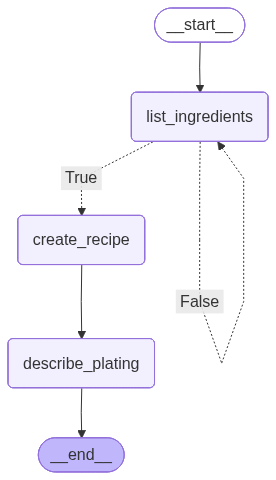

In [25]:
graph_builder = StateGraph(State)

graph_builder.add_node("list_ingredients", list_ingredients)
graph_builder.add_node("create_recipe", create_recipe)
graph_builder.add_node("describe_plating", describe_plating)

graph_builder.add_edge(START, "list_ingredients")
graph_builder.add_conditional_edges("list_ingredients", gate, {
    True : "create_recipe",
    False : "list_ingredients"
})
graph_builder.add_edge("create_recipe", "describe_plating")
graph_builder.add_edge("describe_plating", END)

graph = graph_builder.compile()
graph

In [24]:
# graph.invoke({"dish": "hummus"})